# EPS Production: M9 Glucose vs LB Medium
Compares EPS production capacity (UDPGPT proxy) and growth between M9 minimal medium and LB rich medium using iML1515.

In [1]:
from cobra.io import read_sbml_model
from cobra import Reaction
import pandas as pd

model = read_sbml_model('iML1515.xml')
print(model)

iML1515


## Add EPS Pathways
Three EPS pathways added from `eps_analysis.ipynb`. These are not in the base iML1515 and must be added manually each session.

- **Cellulose** (bcsA): `udpg_c + cdigmp_c → cellulose_c`
- **Colanic acid** (Wca): `udcpgl_c + udpgal_c + udpglcur_c + 2×gdpfuc_c + pep_c → colacid_c` — this is the main EPS proxy and what drives UDPGPT flux
- **PNAG** (pgaB): exports periplasmic `puacgam_p` to extracellular

In [2]:
from cobra import Reaction, Metabolite

# ── Pathway 1: Cellulose (bcsA) ──────────────────────────────────────────────
cel_c = Metabolite('cellulose_c', compartment='c', formula='C6H10O5')
cel_e = Metabolite('cellulose_e', compartment='e', formula='C6H10O5')

r_celsynth = Reaction('CELSYNTH', lower_bound=0.0, upper_bound=1000.0)
r_celsynth.add_metabolites({
    model.metabolites.get_by_id('udpg_c'):   -1.0,
    model.metabolites.get_by_id('cdigmp_c'): -0.001,
    model.metabolites.get_by_id('udp_c'):     1.0,
    cel_c:                                    1.0,
})
r_celt  = Reaction('CELLULOSEt',    lower_bound=0.0, upper_bound=1000.0)
r_celt.add_metabolites({cel_c: -1.0, cel_e: 1.0})
r_celex = Reaction('EX_cellulose_e', lower_bound=0.0, upper_bound=1000.0)
r_celex.add_metabolites({cel_e: -1.0})

# ── Pathway 2: Colanic acid (Wca) ─────────────────────────────────────────────
# COLASYNTH consumes udcpgl_c (the UDPGPT product) — this is what drives UDPGPT flux
col_c = Metabolite('colacid_c', compartment='c', formula='C33H52O27', name='Colanic acid repeating unit')
col_e = Metabolite('colacid_e', compartment='e', formula='C33H52O27', name='Colanic acid (extracellular)')

r_cola = Reaction('COLASYNTH', lower_bound=0.0, upper_bound=1000.0, name='Colanic acid synthase (Wca)')
r_cola.add_metabolites({
    model.metabolites.get_by_id('udcpgl_c'):   -1.0,
    model.metabolites.get_by_id('udpgal_c'):   -1.0,
    model.metabolites.get_by_id('udpglcur_c'): -1.0,
    model.metabolites.get_by_id('gdpfuc_c'):   -2.0,
    model.metabolites.get_by_id('pep_c'):      -1.0,
    col_c:                                      1.0,
    model.metabolites.get_by_id('udcpp_c'):     1.0,
    model.metabolites.get_by_id('udp_c'):       2.0,
    model.metabolites.get_by_id('gdp_c'):       2.0,
    model.metabolites.get_by_id('pi_c'):        1.0,
})
r_colat  = Reaction('COLAIDt',       lower_bound=0.0, upper_bound=1000.0)
r_colat.add_metabolites({col_c: -1.0, col_e: 1.0})
r_colaex = Reaction('EX_colacid_e',  lower_bound=0.0, upper_bound=1000.0)
r_colaex.add_metabolites({col_e: -1.0})

# ── Pathway 3: PNAG export (pgaB) ────────────────────────────────────────────
# Most of the PNAG pathway already exists in iML1515 — only extracellular export is missing
pnag_e   = Metabolite('puacgam_e', compartment='e', name='PNAG (extracellular)')
r_pnagex1 = Reaction('PUACGAMex',    lower_bound=0.0, upper_bound=1000.0)
r_pnagex1.add_metabolites({model.metabolites.get_by_id('puacgam_p'): -1.0, pnag_e: 1.0})
r_pnagex2 = Reaction('EX_puacgam_e', lower_bound=0.0, upper_bound=1000.0)
r_pnagex2.add_metabolites({pnag_e: -1.0})

model.add_reactions([r_celsynth, r_celt, r_celex,
                     r_cola, r_colat, r_colaex,
                     r_pnagex1, r_pnagex2])

print(f"Model now has {len(model.reactions)} reactions")
print(f"CELSYNTH:  {model.reactions.get_by_id('CELSYNTH').reaction}")
print(f"COLASYNTH: {model.reactions.get_by_id('COLASYNTH').reaction}")
print(f"PUACGAMex: {model.reactions.get_by_id('PUACGAMex').reaction}")

Model now has 2720 reactions
CELSYNTH:  0.001 cdigmp_c + udpg_c --> cellulose_c + udp_c
COLASYNTH: 2.0 gdpfuc_c + pep_c + udcpgl_c + udpgal_c + udpglcur_c --> colacid_c + 2.0 gdp_c + pi_c + udcpp_c + 2.0 udp_c
PUACGAMex: puacgam_p --> puacgam_e


## Define Media

### Standard LB Broth Components (per Liter)

- **Tryptone/Casein Hydrolysate (10 g):** Provides essential amino acids and peptides.
- **Yeast Extract (5 g):** Provides vitamins, minerals, and growth factors.
- **Sodium Chloride (10 g):** Maintains osmotic balance for bacterial cells.
- **Distilled Water (H2O):** Up to 1 Liter

### Expasy Composition of Casein
Amino acid fluxes are set proportional to casein composition (Expasy ProtParam):

| AA  | Count | % |
|-----|-------|------|
| Ala (A) | 15 | 4.5% |
| Arg (R) | 22 | 6.5% |
| Asn (N) | 10 | 3.0% |
| Asp (D) | 17 | 5.1% |
| Cys (C) |  5 | 1.5% |
| Gln (Q) | 19 | 5.7% |
| Glu (E) | 19 | 5.7% |
| Gly (G) | 24 | 7.1% |
| His (H) | 10 | 3.0% |
| Ile (I) | 16 | 4.8% |
| Leu (L) | 36 | 10.7% |
| Lys (K) | 24 | 7.1% |
| Met (M) | 12 | 3.6% |
| Phe (F) | 18 | 5.4% |
| Pro (P) | 13 | 3.9% |
| Ser (S) | 27 | 8.0% |
| Thr (T) | 14 | 4.2% |
| Trp (W) |  4 | 1.2% |
| Tyr (Y) | 15 | 4.5% |
| Val (V) | 16 | 4.8% |

In [3]:
# M9 minimal medium, restricted variant (kept for reference/comparison only).
# Renamed from `m9_medium` to `m9_medium_restricted` -- this manually caps
# O2/NH4/Pi/SO4 at values (20/10/10/10) that aren't tied to a cited source and
# are stricter than the standard GEM/iML1515 convention for "M9 minimal medium"
# (only the carbon source is uptake-limited; O2/N/P/S are left unconstrained
# because in a real M9 culture those salts are provided in molar excess and
# never actually become growth-limiting). NOT used as the M9 baseline below.
m9_medium_restricted = {
    'EX_glc__D_e': 10.0,    # glucose as sole carbon source
    'EX_o2_e':     20.0,
    'EX_nh4_e':    10.0,
    'EX_pi_e':     10.0,
    'EX_so4_e':    10.0,
    'EX_h2o_e':    1000.0,
    'EX_h_e':      1000.0,
    'EX_na1_e':    1000.0,
    'EX_k_e':      1000.0,
    'EX_mg2_e':    1000.0,
    'EX_ca2_e':    1000.0,
    'EX_cl_e':     1000.0,
    'EX_fe2_e':    1000.0,
    'EX_mn2_e':    1000.0,
    'EX_zn2_e':    1000.0,
    'EX_cu2_e':    1000.0,
    'EX_cobalt2_e':1000.0,
    'EX_mobd_e':   1000.0,
    'EX_ni2_e':    1000.0,
}

# M9 baseline used going forward: the model's own default SBML exchange bounds.
# This is the standard GEM/iML1515 convention (glucose uptake-limited, everything
# else unconstrained) and matches the canonical six-condition table already
# published in report/project_summary.txt (baseline mu_max = 0.877 h-1).
m9_medium_default = model.medium.copy()

# LB rich medium — casein hydrolysate amino acids + yeast extract vitamins
lb_medium = {
    # salts / ions
    'EX_pi_e':      1000.0,
    'EX_ni2_e':     10000.0,
    'EX_so4_e':     10000.0,
    'EX_o2_e':      23.0,
    'EX_na1_e':     1000.0,
    'EX_cl_e':      1000.0,
    'EX_k_e':       1000.0,
    'EX_mg2_e':     1000.0,
    'EX_ca2_e':     1000.0,
    'EX_fe2_e':     1000.0,
    'EX_mn2_e':     1000.0,
    'EX_zn2_e':     1000.0,
    'EX_cu2_e':     1000.0,
    'EX_cobalt2_e': 1000.0,
    'EX_mobd_e':    1000.0,
    # amino acids (casein hydrolysate, proportional to composition)
    'EX_ala__L_e':  39.89,
    'EX_arg__L_e':  58.51,
    'EX_asn__L_e':  26.60,
    'EX_asp__L_e':  45.21,
    'EX_cys__L_e':  13.30,
    'EX_gln__L_e':  50.53,
    'EX_glu__L_e':  50.53,
    'EX_gly_e':     63.83,
    'EX_his__L_e':  26.60,
    'EX_ile__L_e':  42.55,
    'EX_leu__L_e':  95.74,
    'EX_lys__L_e':  63.83,
    'EX_met__L_e':  31.91,
    'EX_phe__L_e':  47.87,
    'EX_pro__L_e':  34.57,
    'EX_ser__L_e':  71.81,
    'EX_thr__L_e':  37.23,
    'EX_trp__L_e':  10.64,
    'EX_tyr__L_e':  39.89,
    'EX_val__L_e':  42.55,
    # vitamins (yeast extract)
    'EX_thm_e':     1000.0,
    'EX_nac_e':     1000.0,
    'EX_pnto__R_e': 1000.0,
    'EX_pydx_e':    1000.0,
    'EX_btn_e':     1000.0,
}

print('M9 (restricted variant, reference only) components:', len(m9_medium_restricted))
print('M9 (default SBML, used going forward) components:', len(m9_medium_default))
print('LB components:', len(lb_medium))

M9 (restricted variant, reference only) components: 19
M9 (default SBML, used going forward) components: 24
LB components: 40


## EPS Analysis Function
Two-stage optimization:
1. Maximize biomass to find `mu_max`
2. Constrain biomass ≥ 90% of `mu_max`, then maximize `EX_colacid_e` (colanic acid secretion — the main EPS output)

All three EPS secretion fluxes are reported alongside the upstream pathway reactions.

In [4]:
BIOMASS_RXN = 'BIOMASS_Ec_iML1515_core_75p37M'
EPS_RXN     = 'EX_colacid_e'   # colanic acid secretion — main EPS output

# upstream pathway reactions + all three EPS secretion outputs
EPS_RXNS = [
    'UDPGPT',        # wcaJ — colanic acid initiation
    'COLASYNTH',     # Wca — colanic acid assembly
    'EX_colacid_e',  # colanic acid secretion
    'CELSYNTH',      # bcsA — cellulose synthesis
    'EX_cellulose_e',# cellulose secretion
    'EX_puacgam_e',  # PNAG secretion
    'PMANM',         # cpsG — mannose precursor
    'RHCCE',         # luxS — quorum sensing / AI-2
    'AI2K',
]

def run_eps_analysis(base_model, medium, biomass_fraction=0.9):
    m = base_model.copy()
    m.medium = medium

    # Stage 1: maximize growth
    m.objective = BIOMASS_RXN
    sol_growth = m.optimize()
    mu_max = sol_growth.objective_value

    # Stage 2: constrain growth, maximize colanic acid secretion
    biomass_rxn = m.reactions.get_by_id(BIOMASS_RXN)
    biomass_rxn.lower_bound = biomass_fraction * mu_max
    m.objective = EPS_RXN
    sol_eps = m.optimize()

    result = {
        'mu_max':         mu_max,
        'biomass_at_eps': sol_eps.fluxes[BIOMASS_RXN],
    }
    for rxn_id in EPS_RXNS:
        result[rxn_id] = sol_eps.fluxes[rxn_id]

    return result

## Run Both Conditions

In [5]:
# NOTE: switched from m9_medium_restricted to m9_medium_default (the model's own
# default SBML exchange bounds) so this M9 baseline matches the convention used
# everywhere else in the project (eps_analysis.ipynb v3, and the Phase 7
# six-condition section below).
m9_results = run_eps_analysis(model, m9_medium_default)
lb_results = run_eps_analysis(model, lb_medium)

print('M9 results:', m9_results)
print('LB results:', lb_results)

M9 results: {'mu_max': 0.8769972144269655, 'biomass_at_eps': np.float64(0.789297492984269), 'UDPGPT': np.float64(0.1677266187050687), 'COLASYNTH': np.float64(0.1677266187050687), 'EX_colacid_e': np.float64(0.1677266187050687), 'CELSYNTH': np.float64(0.0), 'EX_cellulose_e': np.float64(0.0), 'EX_puacgam_e': np.float64(0.0), 'PMANM': np.float64(-0.3354532374101374), 'RHCCE': np.float64(0.0003536052768569525), 'AI2K': np.float64(0.0003536052768569525)}
LB results: {'mu_max': 1.9527099327190323, 'biomass_at_eps': np.float64(1.757438939447129), 'UDPGPT': np.float64(0.4758855127317061), 'COLASYNTH': np.float64(0.47588551273170615), 'EX_colacid_e': np.float64(0.47588551273170604), 'CELSYNTH': np.float64(0.0), 'EX_cellulose_e': np.float64(0.0), 'EX_puacgam_e': np.float64(0.0), 'PMANM': np.float64(-0.951771025463412), 'RHCCE': np.float64(0.0007838177669831932), 'AI2K': np.float64(0.0007838177669831923)}


## Comparison Table

In [6]:
comparison = pd.DataFrame({
    'M9 Glucose': m9_results,
    'LB Medium':  lb_results
})

comparison.index.name = 'metric'
comparison['fold_change (LB/M9)'] = (comparison['LB Medium'] / comparison['M9 Glucose']).round(2)

print(comparison.to_string())

                M9 Glucose  LB Medium  fold_change (LB/M9)
metric                                                    
mu_max            0.876997   1.952710                 2.23
biomass_at_eps    0.789297   1.757439                 2.23
UDPGPT            0.167727   0.475886                 2.84
COLASYNTH         0.167727   0.475886                 2.84
EX_colacid_e      0.167727   0.475886                 2.84
CELSYNTH          0.000000   0.000000                  NaN
EX_cellulose_e    0.000000   0.000000                  NaN
EX_puacgam_e      0.000000   0.000000                  NaN
PMANM            -0.335453  -0.951771                 2.84
RHCCE             0.000354   0.000784                 2.22
AI2K              0.000354   0.000784                 2.22


## Notes on EPS Components

### Why CELSYNTH = 0
Cellulose synthesis requires c-di-GMP as a cofactor. FBA does not produce c-di-GMP during normal growth because it is not required for biomass. Cellulose is more relevant to mature biofilm architecture, not initial attachment, and is naturally low in E. coli K-12 strains. To activate cellulose flux, a biofilm-inducing state must be simulated by knocking out the c-di-GMP degradation reactions (CDGUNPD, LDGUNPD) to allow c-di-GMP to accumulate.

### Do we need PNAG?
Depends on the experimental assay:
- **Bulk polysaccharide assay** (e.g. phenol-sulfuric acid, crystal violet): PNAG should be included as it contributes to total EPS.
- **Colanic acid-specific assay** (e.g. fucose-based colorimetric): colanic acid alone is sufficient.

In E. coli K-12 (iML1515), colanic acid is the dominant secreted EPS. PNAG is partially retained at the cell surface as an adhesin rather than fully secreted, so it may not appear in supernatant-based EPS measurements. `EX_colacid_e` is the primary EPS proxy in this model. PNAG (`EX_puacgam_e`) is present and can be activated by changing the optimization objective if needed.

## LB-Only: All Three EPS Pathways, Each Individually Maximized

Going forward this project works exclusively in **LB medium** (rich, faster growth). Before moving
from static FBA to dFBA/hybrid-FBA, we need a complete static baseline: the point-estimate flux for
**each of the three EPS pathways**, individually maximized, under LB.

Two-stage FBA per pathway (biomass max -> 90% floor -> maximize that pathway's exchange reaction),
using **pFBA** for stage 2 to avoid degenerate high-flux solutions:

- `EX_colacid_e` (colanic acid) — carries flux under normal LB conditions, no knockouts needed
- `EX_puacgam_e` (PNAG) — carries flux under normal LB conditions, no knockouts needed
- `EX_cellulose_e` (cellulose) — requires `CDGUNPD` + `LDGUNPD` knocked out (blocks c-di-GMP
  degradation) or CELSYNTH stays at 0, per the biology notes above

In [7]:
from cobra.flux_analysis import pfba

def run_pathway_max_lb(base_model, medium, eps_rxn_id, biomass_fraction=0.9, knockouts=None):
    """Two-stage FBA: maximize biomass, constrain to biomass_fraction*mu_max,
    then pFBA-maximize a single EPS exchange reaction. Optional knockouts (list of
    reaction IDs) are applied before stage 1 (e.g. c-di-GMP degradation KO for cellulose)."""
    m = base_model.copy()
    m.medium = medium

    if knockouts:
        for rxn_id in knockouts:
            rxn = m.reactions.get_by_id(rxn_id)

            rxn.lower_bound = 0.0
            rxn.upper_bound = 0.0
            

    # Stage 1: maximize growth
    m.objective = BIOMASS_RXN
    sol_growth = m.optimize()
    mu_max = sol_growth.objective_value

    # Stage 2: constrain growth, pFBA-maximize the target EPS exchange reaction
    biomass_rxn = m.reactions.get_by_id(BIOMASS_RXN)
    biomass_rxn.lower_bound = biomass_fraction * mu_max
    m.objective = eps_rxn_id
    sol_eps = pfba(m)

    return {
        'mu_max':          mu_max,
        'biomass_at_eps':  sol_eps.fluxes[BIOMASS_RXN],
        'eps_flux':        sol_eps.fluxes[eps_rxn_id],
        'knockouts':       knockouts if knockouts else [],
    }

lb_cellulose = run_pathway_max_lb(model, lb_medium, 'EX_cellulose_e',
                                   knockouts=['CDGUNPD', 'LDGUNPD'])
lb_colacid   = run_pathway_max_lb(model, lb_medium, 'EX_colacid_e')
lb_pnag      = run_pathway_max_lb(model, lb_medium, 'EX_puacgam_e')

print('LB cellulose (c-di-GMP KO):', lb_cellulose)
print('LB colanic acid:           ', lb_colacid)
print('LB PNAG:                   ', lb_pnag)

LB cellulose (c-di-GMP KO): {'mu_max': 1.9527099327190829, 'biomass_at_eps': np.float64(1.7574389394471746), 'eps_flux': np.float64(2.1842516809527437), 'knockouts': ['CDGUNPD', 'LDGUNPD']}
LB colanic acid:            {'mu_max': 1.9527099327190323, 'biomass_at_eps': np.float64(1.757438939447129), 'eps_flux': np.float64(0.47588551273170665), 'knockouts': []}
LB PNAG:                    {'mu_max': 1.9527099327190323, 'biomass_at_eps': np.float64(1.757438939447129), 'eps_flux': np.float64(2.314266666666936), 'knockouts': []}


In [8]:
# Per-cell unit conversion (project standard)
DW_PER_CELL_G = 2.8e-13  # E. coli dry weight ~= 280 fg/cell
MW = {'Cellulose': 162.14, 'Colanic acid': 588, 'PNAG': 221.21}  # g/mol

lb_pathway_summary = pd.DataFrame({
    'Cellulose':    {'mu_max': lb_cellulose['mu_max'], 'biomass_at_eps': lb_cellulose['biomass_at_eps'],
                      'eps_flux_mmol_gDW_h': lb_cellulose['eps_flux'], 'knockouts': lb_cellulose['knockouts']},
    'Colanic acid': {'mu_max': lb_colacid['mu_max'],   'biomass_at_eps': lb_colacid['biomass_at_eps'],
                      'eps_flux_mmol_gDW_h': lb_colacid['eps_flux'],   'knockouts': lb_colacid['knockouts']},
    'PNAG':         {'mu_max': lb_pnag['mu_max'],      'biomass_at_eps': lb_pnag['biomass_at_eps'],
                      'eps_flux_mmol_gDW_h': lb_pnag['eps_flux'],      'knockouts': lb_pnag['knockouts']},
}).T

lb_pathway_summary['fg_per_cell_per_h'] = [
    lb_pathway_summary.loc[p, 'eps_flux_mmol_gDW_h'] * DW_PER_CELL_G * MW[p] * 1e15
    for p in lb_pathway_summary.index
]

print(lb_pathway_summary.to_string())
lb_pathway_summary.to_csv('eps_lb_three_pathways.csv')

               mu_max biomass_at_eps eps_flux_mmol_gDW_h           knockouts  fg_per_cell_per_h
Cellulose     1.95271       1.757439            2.184252  [CDGUNPD, LDGUNPD]       99163.278914
Colanic acid  1.95271       1.757439            0.475886                  []       78349.790816
PNAG          1.95271       1.757439            2.314267                  []      143342.900213


## LB Six-Condition Analysis (v4) — Full Condition Matrix in LB, vs M9

**Why:** the collaborator running these simulations works exclusively in LB. The
six standard conditions (`baseline`, `high_glucose`, `low_oxygen`, `N_limited`,
`EPS_phenotype`, `combined_EPS`) were only ever run in M9 (`eps_analysis.ipynb`,
"EPS Model v3"). This section reruns the same six conditions with LB as the base
medium so results are directly comparable to the established M9 table.

Two of the six conditions are **not** a simple copy of their M9 definition, because
LB's nutrient structure is fundamentally different from M9's single-carbon /
single-nitrogen-source design:

| Condition | M9 definition | LB definition (this section) | Why it's different |
|---|---|---|---|
| `baseline` | glucose 10, NH4+ 10, unlimited O2/P/S | `lb_medium` as-is (no glucose, no free NH4+) | LB has no single carbon/nitrogen source — amino acids serve both roles |
| `high_glucose` | `EX_glc__D_e` 10→20 | `lb_medium` + `EX_glc__D_e`=20.0 (glucose-*supplemented* LB) | LB has no baseline glucose to double — this models "LB + 0.2% glucose", a real lab practice |
| `low_oxygen` | `EX_o2_e` 20→5 | `EX_o2_e` 23→5 (same absolute target as M9) | Matched to the same numeric O2 cap so severity is comparable across media |
| `N_limited` | `EX_nh4_e` 10→2 (80% cut, the *sole* N source) | all 20 amino-acid exchange bounds scaled to 20% of their LB baseline value | `EX_nh4_e` isn't even in `lb_medium` — cobra's `model.medium` setter closes any exchange not listed, so NH4+ uptake is already 0 in LB. The real N source is the amino acids, so N-limitation must act on those instead |
| `EPS_phenotype` | `CDGUNPD`+`LDGUNPD` knocked out | same knockouts, LB baseline medium unchanged | ports over directly |
| `combined_EPS` | `high_glucose` + `N_limited` + knockouts | LB + glucose supplement + 20%-scaled amino acids + knockouts | same compound logic as M9 |

**Caveat found while implementing this (important for interpreting the results below):**
amino acids in LB are *both* carbon and nitrogen sources. Scaling them all down
uniformly restricts carbon supply at the same time as nitrogen supply, so it does
**not** reproduce the sharp carbon-excess / nitrogen-scarce imbalance that drives
EPS overflow metabolism in the M9 `N_limited` condition (where glucose stays
unrestricted while NH4+ alone is cut). This is expected to make `N_limited` /
`combined_EPS` look much weaker in LB than in M9 — that is a real biological
difference in how the two media can be nitrogen-starved, not a modeling bug.
Confirmed in the results below and discussed further there.

**M9 baseline convention (resolved):** the M9 side of this comparison uses the
model's own default SBML exchange bounds (`m9_medium_default`, defined a few
cells up) — the standard GEM/iML1515 convention (glucose uptake-limited,
everything else unconstrained) — exactly as `eps_analysis.ipynb` v3 does, and
now also exactly as the "Run Both Conditions" section earlier in *this* notebook
does (updated to match). Previously that earlier section used a stricter,
uncited variant (now renamed `m9_medium_restricted`, kept only for reference)
that gave a different baseline growth rate (0.822 h⁻¹ vs 0.877 h⁻¹) — this
inconsistency has been resolved by standardizing on `m9_medium_default`
everywhere in this notebook.

In [9]:
# ── Amino-acid exchanges in lb_medium (used to scale N-limitation) ───────────
AA_EXCHANGES = [
    'EX_ala__L_e', 'EX_arg__L_e', 'EX_asn__L_e', 'EX_asp__L_e', 'EX_cys__L_e',
    'EX_gln__L_e', 'EX_glu__L_e', 'EX_gly_e',    'EX_his__L_e', 'EX_ile__L_e',
    'EX_leu__L_e', 'EX_lys__L_e', 'EX_met__L_e', 'EX_phe__L_e', 'EX_pro__L_e',
    'EX_ser__L_e', 'EX_thr__L_e', 'EX_trp__L_e', 'EX_tyr__L_e', 'EX_val__L_e',
]
assert all(aa in lb_medium for aa in AA_EXCHANGES)

def scale_amino_acids(medium, factor):
    """Scale all 20 amino-acid uptake bounds by `factor`, leaving everything else
    (salts, vitamins, O2, glucose if present) unchanged. Used to simulate
    N-limitation in LB, where amino acids are the only nitrogen source."""
    m = medium.copy()
    for aa in AA_EXCHANGES:
        m[aa] = m[aa] * factor
    return m

# ── Six M9 conditions (reference — matches eps_analysis.ipynb v3 exactly) ────
# Uses m9_medium_default (the model's own default SBML exchange bounds) as the
# M9 base medium -- NOT m9_medium_restricted. See markdown note above for why.
m9_conditions = {
    'baseline':      {'medium_changes': {},                                    'knockouts': []},
    'high_glucose':  {'medium_changes': {'EX_glc__D_e': 20.0},                'knockouts': []},
    'low_oxygen':    {'medium_changes': {'EX_o2_e': 5.0},                     'knockouts': []},
    'N_limited':     {'medium_changes': {'EX_nh4_e': 2.0},                    'knockouts': []},
    'EPS_phenotype': {'medium_changes': {},                                    'knockouts': ['CDGUNPD', 'LDGUNPD']},
    'combined_EPS':  {'medium_changes': {'EX_glc__D_e': 20.0, 'EX_nh4_e': 2.0}, 'knockouts': ['CDGUNPD', 'LDGUNPD']},
}

# ── Six LB conditions (new) — see markdown table above for definitions ───────
lb_conditions = {
    'baseline':      {'medium': lb_medium,                                              'knockouts': []},
    'high_glucose':  {'medium': {**lb_medium, 'EX_glc__D_e': 20.0},                     'knockouts': []},
    'low_oxygen':    {'medium': {**lb_medium, 'EX_o2_e': 5.0},                          'knockouts': []},
    'N_limited':     {'medium': scale_amino_acids(lb_medium, 0.2),                      'knockouts': []},
    'EPS_phenotype': {'medium': lb_medium,                                              'knockouts': ['CDGUNPD', 'LDGUNPD']},
    'combined_EPS':  {'medium': scale_amino_acids({**lb_medium, 'EX_glc__D_e': 20.0}, 0.2),
                       'knockouts': ['CDGUNPD', 'LDGUNPD']},
}

print('M9 conditions:', list(m9_conditions))
print('LB conditions:', list(lb_conditions))

M9 conditions: ['baseline', 'high_glucose', 'low_oxygen', 'N_limited', 'EPS_phenotype', 'combined_EPS']
LB conditions: ['baseline', 'high_glucose', 'low_oxygen', 'N_limited', 'EPS_phenotype', 'combined_EPS']


In [10]:
# ── Condition-matrix runner: all three EPS pathways, each pFBA-maximized ─────
# Same two-stage pattern used throughout the project:
#   Stage 1: maximize biomass (pFBA) -> mu_max
#   Stage 2: biomass >= 90% mu_max, maximize each EPS exchange reaction in turn

EPS_RXNS_MAP = {'Cellulose': 'EX_cellulose_e', 'Colanic acid': 'EX_colacid_e', 'PNAG': 'EX_puacgam_e'}
DW_PER_CELL_G = 2.8e-13
MW_MAP = {'Cellulose': 162.14, 'Colanic acid': 588, 'PNAG': 221.21}

def run_condition_matrix(base_model, conditions_map, base_m9_medium=None):
    """conditions_map: dict of cond_name -> {'medium' or 'medium_changes', 'knockouts'}.
    If entries have 'medium', that full medium dict is applied directly (LB case).
    If entries have 'medium_changes', they are layered on top of base_m9_medium (M9 case)."""
    results = []
    for cond_name, cfg in conditions_map.items():
        with base_model:
            if 'medium' in cfg:
                base_model.medium = cfg['medium']
            else:
                med = base_m9_medium.copy()
                med.update(cfg['medium_changes'])
                base_model.medium = med

            for rxn_id in cfg['knockouts']:
                rxn = base_model.reactions.get_by_id(rxn_id)
                rxn.lower_bound = 0.0
                rxn.upper_bound = 0.0

            base_model.objective = BIOMASS_RXN
            mu_max = pfba(base_model).fluxes[BIOMASS_RXN]
            base_model.reactions.get_by_id(BIOMASS_RXN).lower_bound = 0.9 * mu_max

            row = {'condition': cond_name, 'mu_max': round(mu_max, 4)}
            for label, rxn_id in EPS_RXNS_MAP.items():
                base_model.objective = rxn_id
                sol = base_model.optimize()
                row[label] = round(sol.fluxes.get(rxn_id, 0.0), 6) if sol.status == 'optimal' else 0.0
            row['Total EPS'] = round(sum(row[k] for k in EPS_RXNS_MAP), 4)
            for label in EPS_RXNS_MAP:
                row[f'fg_{label}'] = row[label] * DW_PER_CELL_G * MW_MAP[label] * 1e15
            row['fg_total'] = sum(row[f'fg_{k}'] for k in EPS_RXNS_MAP)
            results.append(row)
    return pd.DataFrame(results)

print("=== M9 six-condition matrix (reproduces eps_analysis.ipynb v3) ===")
df_m9_v4 = run_condition_matrix(model, m9_conditions, base_m9_medium=m9_medium_default)
print(df_m9_v4[['condition','mu_max','Cellulose','Colanic acid','PNAG','Total EPS']].to_string(index=False))

print("\n=== LB six-condition matrix (new) ===")
df_lb_v4 = run_condition_matrix(model, lb_conditions)
print(df_lb_v4[['condition','mu_max','Cellulose','Colanic acid','PNAG','Total EPS']].to_string(index=False))

df_m9_v4.to_csv('eps_v4_m9_six_conditions.csv', index=False)
df_lb_v4.to_csv('eps_v4_lb_six_conditions.csv', index=False)
print("\nSaved: eps_v4_m9_six_conditions.csv, eps_v4_lb_six_conditions.csv")

=== M9 six-condition matrix (reproduces eps_analysis.ipynb v3) ===


    condition  mu_max  Cellulose  Colanic acid     PNAG  Total EPS
     baseline  0.8770   0.902271      0.167727 0.675768     1.7458
 high_glucose  1.7798   1.831090      0.340388 1.371420     3.5429
   low_oxygen  0.3535   0.946731      0.172936 0.625231     1.7449
    N_limited  0.1852   7.247322      1.346743 0.200000     8.7941
EPS_phenotype  0.8770   0.902271      0.167727 0.675768     1.7458
 combined_EPS  0.1852  16.438854      3.056714 0.200000    19.6956

=== LB six-condition matrix (new) ===


    condition  mu_max  Cellulose  Colanic acid     PNAG  Total EPS
     baseline  1.9527   2.184252      0.475886 2.314267     4.9744
 high_glucose  3.0652   4.898921      1.063286 4.683524    10.6457
   low_oxygen  0.7686   0.870850      0.192212 0.986130     2.0492
    N_limited  1.2990   1.200794      0.249625 1.166937     2.6174
EPS_phenotype  1.9527   2.184252      0.475886 2.314267     4.9744
 combined_EPS  2.1596   4.379046      0.902928 3.568714     8.8507

Saved: eps_v4_m9_six_conditions.csv, eps_v4_lb_six_conditions.csv


In [11]:
# ── M9 vs LB comparison table with fold-changes ──────────────────────────────
comp_v4 = df_m9_v4[['condition','mu_max','Cellulose','Colanic acid','PNAG','Total EPS']].merge(
    df_lb_v4[['condition','mu_max','Cellulose','Colanic acid','PNAG','Total EPS']],
    on='condition', suffixes=('_M9', '_LB')
)
comp_v4['mu_fold_LB_over_M9']        = (comp_v4['mu_max_LB'] / comp_v4['mu_max_M9']).round(2)
comp_v4['TotalEPS_fold_LB_over_M9']  = (comp_v4['Total EPS_LB'] / comp_v4['Total EPS_M9']).round(2)

print(comp_v4.to_string(index=False))
comp_v4.to_csv('eps_m9_vs_lb_six_conditions_comparison.csv', index=False)
print("\nSaved: eps_m9_vs_lb_six_conditions_comparison.csv")

    condition  mu_max_M9  Cellulose_M9  Colanic acid_M9  PNAG_M9  Total EPS_M9  mu_max_LB  Cellulose_LB  Colanic acid_LB  PNAG_LB  Total EPS_LB  mu_fold_LB_over_M9  TotalEPS_fold_LB_over_M9
     baseline     0.8770      0.902271         0.167727 0.675768        1.7458     1.9527      2.184252         0.475886 2.314267        4.9744                2.23                      2.85
 high_glucose     1.7798      1.831090         0.340388 1.371420        3.5429     3.0652      4.898921         1.063286 4.683524       10.6457                1.72                      3.00
   low_oxygen     0.3535      0.946731         0.172936 0.625231        1.7449     0.7686      0.870850         0.192212 0.986130        2.0492                2.17                      1.17
    N_limited     0.1852      7.247322         1.346743 0.200000        8.7941     1.2990      1.200794         0.249625 1.166937        2.6174                7.01                      0.30
EPS_phenotype     0.8770      0.902271         0.1

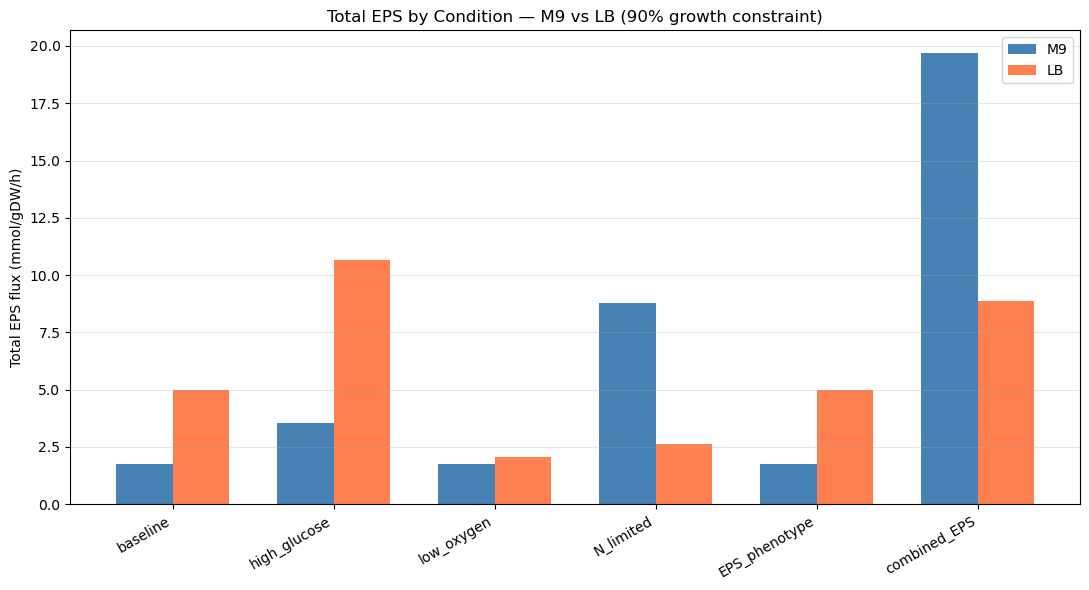

Saved: eps_m9_vs_lb_six_conditions_bars.png


In [12]:
# ── Grouped bar chart: Total EPS, M9 vs LB, per condition ────────────────────
import matplotlib.pyplot as plt
import numpy as np

conds = comp_v4['condition'].tolist()
x = np.arange(len(conds))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, comp_v4['Total EPS_M9'], width, label='M9', color='steelblue')
ax.bar(x + width/2, comp_v4['Total EPS_LB'], width, label='LB', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(conds, rotation=30, ha='right')
ax.set_ylabel('Total EPS flux (mmol/gDW/h)')
ax.set_title('Total EPS by Condition — M9 vs LB (90% growth constraint)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eps_m9_vs_lb_six_conditions_bars.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: eps_m9_vs_lb_six_conditions_bars.png")

### Result: LB N-limitation is much weaker than M9 N-limitation

Running the numbers confirms the caveat flagged above. Comparing `mu_max` drops
from `baseline` to `N_limited`:
- **M9**: 0.877 → 0.185 h⁻¹ (79% growth cut) → Total EPS jumps 1.75 → 8.79 mmol/gDW/h (5x)
- **LB**: 1.953 → 1.299 h⁻¹ (only 33% growth cut) → Total EPS only goes 4.97 → 2.62 mmol/gDW/h (**down**, not up)

Restricting NH4+ alone in M9 leaves glucose (the sole carbon source) completely
unrestricted, creating a sharp carbon-excess/nitrogen-scarce imbalance that forces
carbon overflow into EPS. Scaling all 20 amino acids down uniformly in LB restricts
carbon and nitrogen *together* (amino acids are dual C+N sources), so it never
creates that same imbalance — the cell simply grows a bit slower with proportionally
less of everything, rather than hitting a nitrogen wall with carbon to spare.

`combined_EPS` partially recovers this (LB Total EPS 8.85 vs M9's 19.70, fold 0.45)
because it also adds a glucose supplement on top of the 20%-scaled amino acids,
reintroducing some of that carbon-excess condition — but it still falls well short
of the M9 number.

**Implication for the collaborator:** if LB is the fixed experimental medium, getting
a strong EPS-inducing "N-limited" condition may require a different lever than uniform
amino-acid scaling — e.g., keeping a non-amino-acid carbon source (glucose) fixed and
high while restricting only the amino acids that are poor carbon sources, or reducing
amino acids non-uniformly to preferentially cut nitrogen-rich ones (Arg, Gln, Asn, Lys)
while leaving carbon-only inputs alone. This is flagged as a follow-up design question
rather than resolved here.